# Assignment 4: Data Analytics I (Linear Regression)

This experiment implements a Linear Regression model to predict house prices using the Boston Housing Dataset. The dataset contains various features related to houses, and the target variable is the house price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df = pd.read_csv("Datasets/HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## Dataset Exploration

- `shape` → number of rows and columns  
- `info()` → data types and null values  
- `describe()` → statistical summary  

In [3]:
df.shape


(506, 14)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## Handling Missing Values

Linear Regression cannot handle missing values, so they are replaced using mean imputation.

In [6]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

## Define Features and Target Variable

- Independent variables (X) → all columns except price  
- Dependent variable (y) → house price (MEDV)

In [8]:
x = df.drop("MEDV", axis=1)
y = df["MEDV"]

## Train-Test Split

The dataset is split into training and testing sets:
- 80% → training  
- 20% → testing  

In [9]:
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)

In [10]:
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,15.02340,0.000000,18.10,0.0,0.6140,5.304,97.300000,2.1007,24,666,20.2,349.48,24.91
15,0.62739,0.000000,8.14,0.0,0.5380,5.834,56.500000,4.4986,4,307,21.0,395.62,8.47
332,0.03466,11.211934,6.06,0.0,0.4379,6.031,23.300000,6.6407,1,304,16.9,362.25,7.83
423,7.05042,0.000000,18.10,0.0,0.6140,6.103,68.518519,2.0218,24,666,20.2,2.52,23.29
19,0.72580,0.000000,8.14,0.0,0.5380,5.727,69.500000,3.7965,4,307,21.0,390.95,11.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.000000,8.56,0.0,0.5200,5.836,91.900000,2.2110,5,384,20.9,395.67,18.66
270,0.29916,20.000000,6.96,0.0,0.4640,5.856,42.100000,4.4290,3,223,18.6,388.65,13.00
348,0.01501,80.000000,2.01,0.0,0.4350,6.635,29.700000,8.3440,4,280,17.0,390.94,5.99
435,11.16040,0.000000,18.10,0.0,0.7400,6.629,94.600000,2.1247,24,666,20.2,109.85,23.27


## Model Training

Linear Regression model is trained using training data.

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Prediction

Model predicts house prices using test data.

In [14]:
y_pred = model.predict(X_test)

## Model Evaluation

- MSE → error measure  
- R² → accuracy  

In [15]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 25.01767202384268
R2 Score: 0.6588520195508143


## Visualization

Scatter plot of actual vs predicted values.

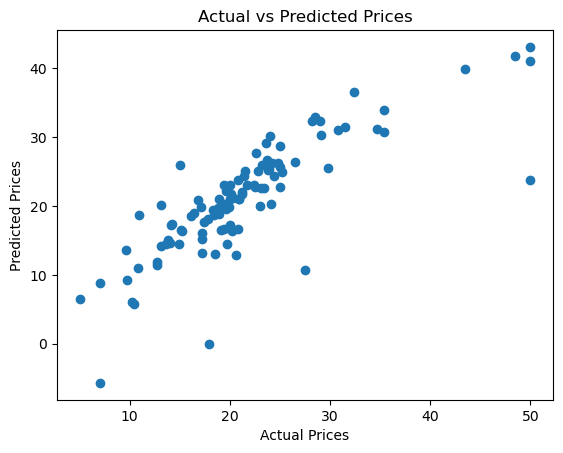

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()